<a href="https://colab.research.google.com/github/76213869-sketch/Sem7_MLP2/blob/main/CS_Parcial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# FASE 2: CARGA CORRECTA DEL DATASET
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar con coma y encoding que elimina el BOM
df = pd.read_csv('dataset.csv', sep=',', encoding='utf-8-sig')

print("=" * 55)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 55)
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\nDistribución de la variable target:")
print(df['Target'].value_counts())
print(f"\nPorcentajes:")
print(df['Target'].value_counts(normalize=True).mul(100).round(2))


INFORMACIÓN GENERAL DEL DATASET
Dimensiones: 4424 filas × 35 columnas

Distribución de la variable target:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Porcentajes:
Target
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64


Distribución clase binaria:
dropout
0    3003
1    1421
Name: count, dtype: int64
Porcentaje Dropout: 32.12%

ESTADÍSTICAS DESCRIPTIVAS POR CLASE (0=No Dropout, 1=Dropout):
dropout                                   0       1
Curricular units 1st sem (approved)   5.726   2.552
Curricular units 1st sem (grade)     12.242   7.257
Curricular units 2nd sem (approved)   5.617   1.940
Curricular units 2nd sem (grade)     12.280   5.899
Age at enrollment                    21.938  26.069
Tuition fees up to date               0.976   0.678
Scholarship holder                    0.321   0.094
Debtor                                0.064   0.220


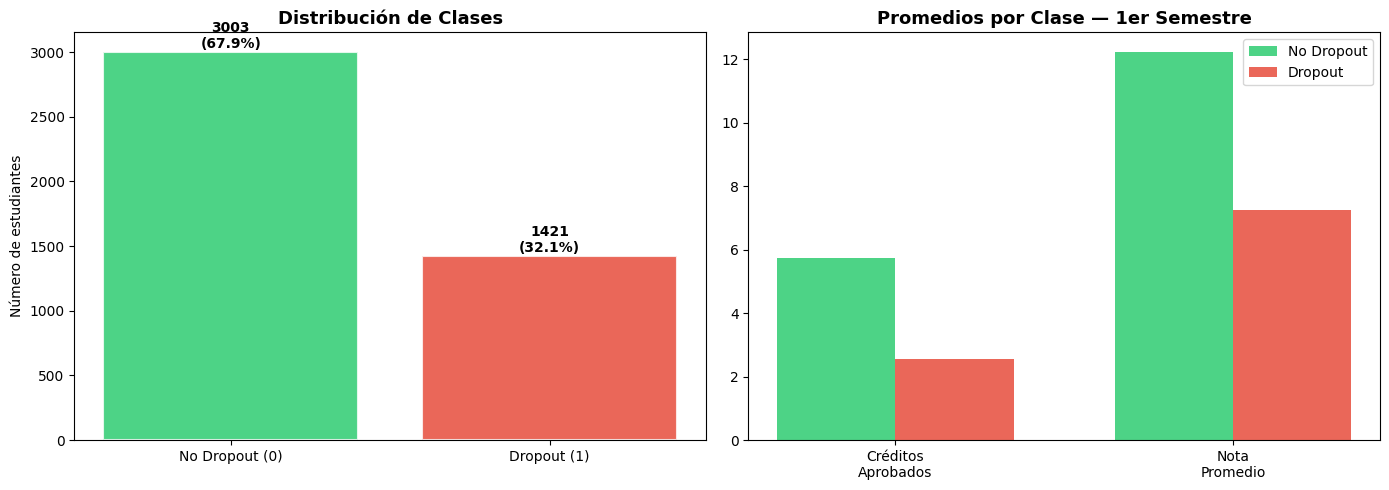

In [ ]:
# ============================================================
# CELDA 2: BINARIZACIÓN Y ANÁLISIS DESCRIPTIVO
# ============================================================

# Binarizar: 1 = Dropout, 0 = Graduate o Enrolled
df['dropout'] = (df['Target'] == 'Dropout').astype(int)

print("Distribución clase binaria:")
print(df['dropout'].value_counts())
print(f"Porcentaje Dropout: {df['dropout'].mean():.2%}\n")

# Variables clave disponibles en ESTE dataset
vars_key = [
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Age at enrollment',
    'Tuition fees up to date',
    'Scholarship holder',
    'Debtor',
]

print("ESTADÍSTICAS DESCRIPTIVAS POR CLASE (0=No Dropout, 1=Dropout):")
print("=" * 60)
print(df.groupby('dropout')[vars_key].mean().T.round(3))

# Visualización: distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['dropout'].value_counts().sort_index()
axes[0].bar(['No Dropout (0)', 'Dropout (1)'],
            counts.values,
            color=['#2ecc71', '#e74c3c'],
            alpha=0.85, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribución de Clases', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de estudiantes')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f'{v}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold')

# Comparativa de medias por clase
medias = df.groupby('dropout')[[
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)'
]].mean()
x = np.arange(len(medias.columns))
width = 0.35
axes[1].bar(x - width/2, medias.loc[0].values, width,
            label='No Dropout', color='#2ecc71', alpha=0.85)
axes[1].bar(x + width/2, medias.loc[1].values, width,
            label='Dropout', color='#e74c3c', alpha=0.85)
axes[1].set_title('Promedios por Clase — 1er Semestre', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Créditos\nAprobados', 'Nota\nPromedio'], fontsize=10)
axes[1].legend()
plt.tight_layout()
plt.savefig('fase2_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_2847/3049158810.py:103: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(


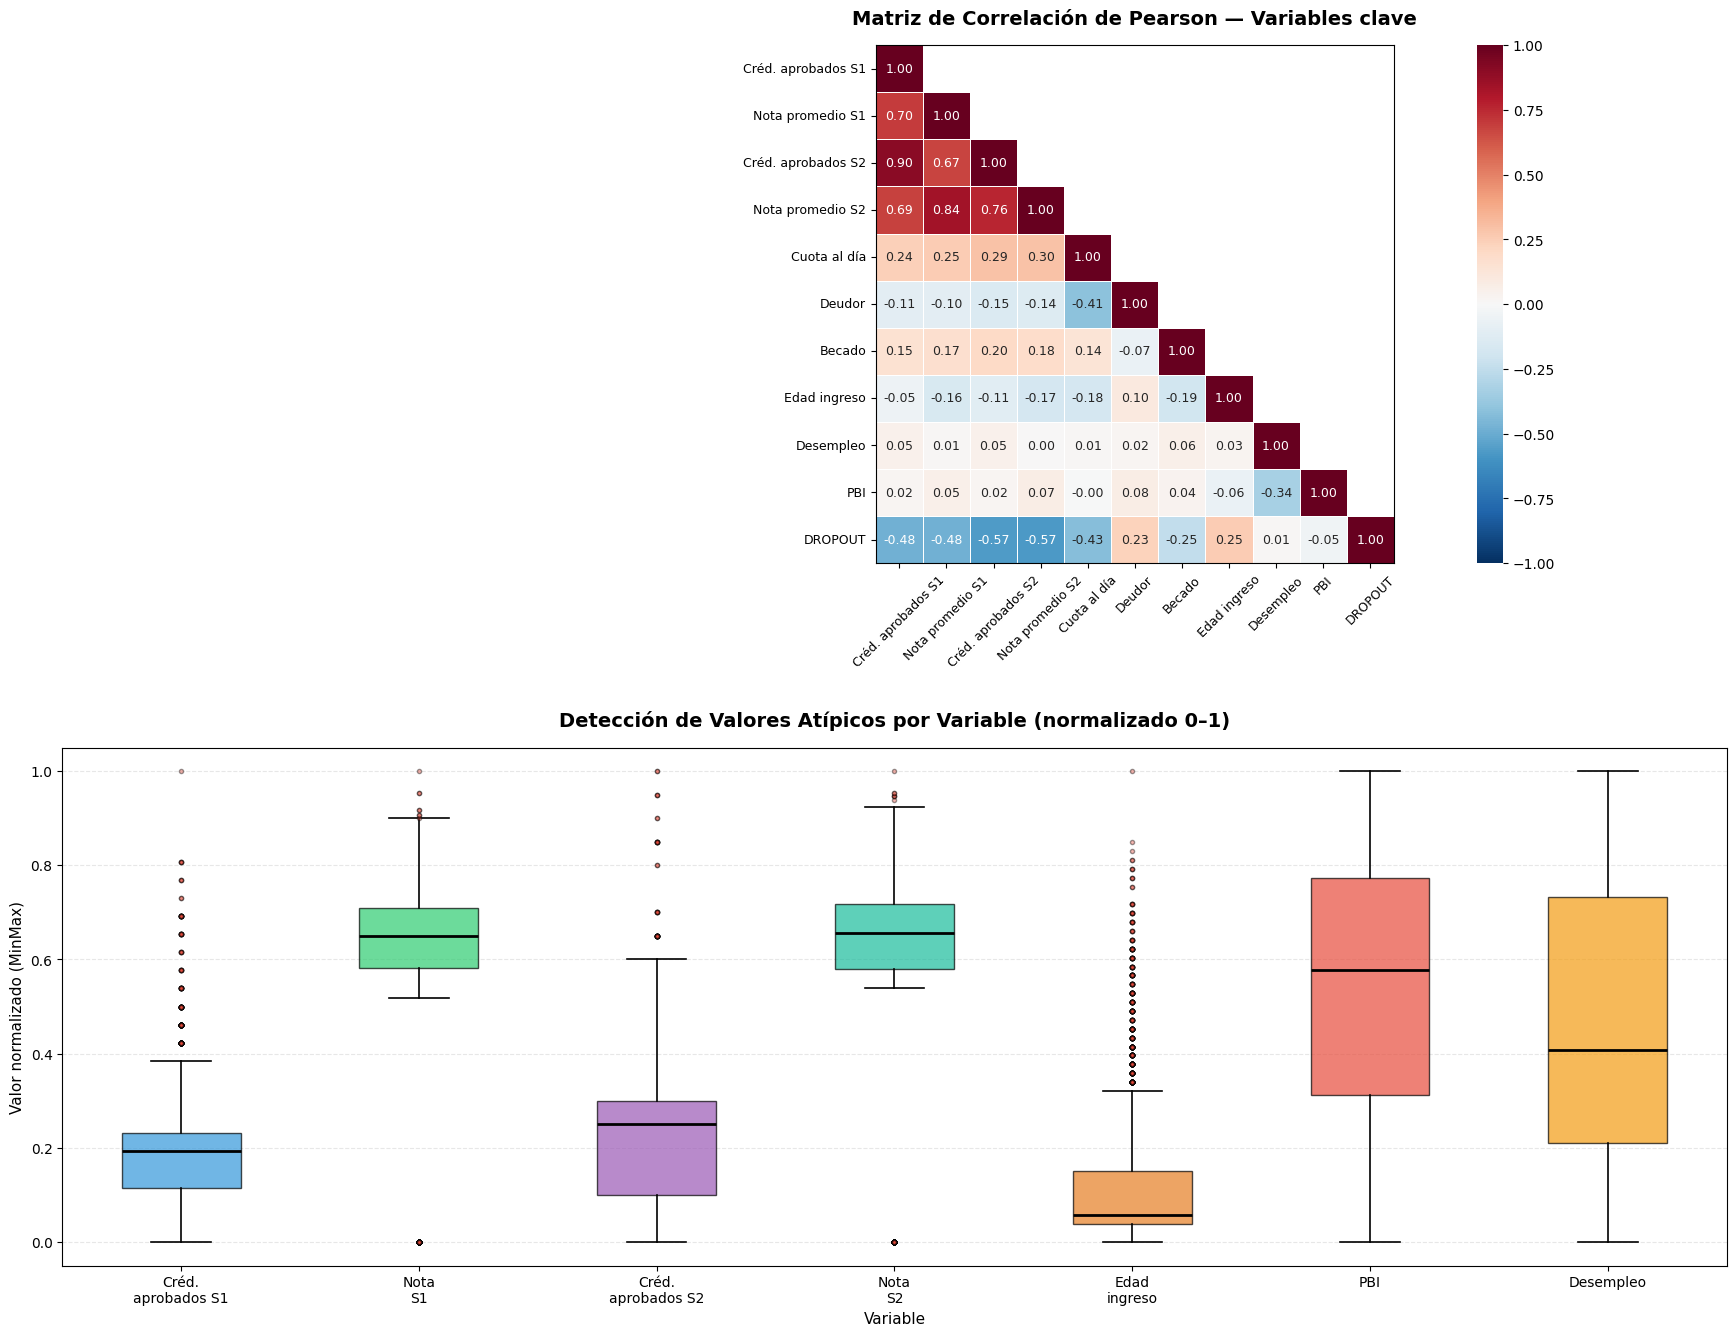


REPORTE DE OUTLIERS (método IQR):
Variable                                 Outliers      %
----------------------------------------------------------
  Curricular units 1st sem (approved)         180  4.07%
  Curricular units 1st sem (grade)            726 16.41%
  Curricular units 2nd sem (approved)          44  0.99%
  Curricular units 2nd sem (grade)            877 19.82%
  Age at enrollment                           441  9.97%
  GDP                                           0  0.00%
  Unemployment rate                             0  0.00%

CORRELACIONES CON DROPOUT (ordenadas por valor absoluto):
  Nota promedio S2          -0.572  (↓ menor dropout)
  Créd. aprobados S2        -0.570  (↓ menor dropout)
  Nota promedio S1          -0.481  (↓ menor dropout)
  Créd. aprobados S1        -0.479  (↓ menor dropout)
  Cuota al día              -0.429  (↓ menor dropout)
  Edad ingreso              +0.254  (↑ mayor dropout)
  Becado                    -0.245  (↓ menor dropout)
  Deudor     

In [ ]:
# ============================================================
# CELDA 3: MATRIZ DE CORRELACIÓN + DETECCIÓN DE OUTLIERS
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- SELECCIONAR VARIABLES NUMÉRICAS RELEVANTES ---
vars_corr = [
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Tuition fees up to date',
    'Debtor',
    'Scholarship holder',
    'Age at enrollment',
    'Unemployment rate',
    'GDP',
    'dropout'   # incluimos el target para ver correlación directa
]

df_corr = df_model[vars_corr].copy()

# Renombrar para que quepan mejor en el gráfico
rename_map = {
    'Curricular units 1st sem (approved)' : 'Créd. aprobados S1',
    'Curricular units 1st sem (grade)'    : 'Nota promedio S1',
    'Curricular units 2nd sem (approved)' : 'Créd. aprobados S2',
    'Curricular units 2nd sem (grade)'    : 'Nota promedio S2',
    'Tuition fees up to date'             : 'Cuota al día',
    'Debtor'                              : 'Deudor',
    'Scholarship holder'                  : 'Becado',
    'Age at enrollment'                   : 'Edad ingreso',
    'Unemployment rate'                   : 'Desempleo',
    'GDP'                                 : 'PBI',
    'dropout'                             : 'DROPOUT'
}
df_corr = df_corr.rename(columns=rename_map)

# --- CALCULAR MATRIZ DE CORRELACIÓN ---
corr_matrix = df_corr.corr()

# --- FIGURA: 2 subplots ---
fig = plt.figure(figsize=(18, 14))

# ── SUBPLOT 1: Heatmap (matriz de correlación) ─────────────
ax1 = fig.add_subplot(2, 1, 1)

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True  # ocultar triángulo superior (redundante)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',       # rojo = correlación negativa, azul = positiva
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    ax=ax1,
    annot_kws={'size': 9}
)
ax1.set_title('Matriz de Correlación de Pearson — Variables clave',
              fontsize=14, fontweight='bold', pad=15)
ax1.tick_params(axis='x', rotation=45, labelsize=9)
ax1.tick_params(axis='y', rotation=0,  labelsize=9)

# Resaltar la fila/columna DROPOUT con un borde
for spine in ax1.spines.values():
    spine.set_visible(True)

# ── SUBPLOT 2: Boxplots para outliers ──────────────────────
ax2 = fig.add_subplot(2, 1, 2)

vars_box = [
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Age at enrollment',
    'GDP',
    'Unemployment rate',
]
labels_box = [
    'Créd.\naprobados S1', 'Nota\nS1',
    'Créd.\naprobados S2', 'Nota\nS2',
    'Edad\ningreso', 'PBI', 'Desempleo'
]

# Normalizar para comparar en la misma escala
from sklearn.preprocessing import MinMaxScaler
scaler_vis = MinMaxScaler()
df_box = pd.DataFrame(
    scaler_vis.fit_transform(df_model[vars_box]),
    columns=labels_box
)

bp = ax2.boxplot(
    [df_box[col].dropna() for col in df_box.columns],
    labels=labels_box,
    patch_artist=True,
    notch=False,
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markersize=3,
                    markerfacecolor='#e74c3c', alpha=0.4),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
)

colors_box = ['#3498db', '#2ecc71', '#9b59b6',
              '#1abc9c', '#e67e22', '#e74c3c', '#f39c12']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_title('Detección de Valores Atípicos por Variable (normalizado 0–1)',
              fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('Valor normalizado (MinMax)', fontsize=11)
ax2.set_xlabel('Variable', fontsize=11)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.tick_params(axis='x', labelsize=10)

plt.tight_layout(pad=3.0)
plt.savefig('fase2_correlacion_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

# ── REPORTE NUMÉRICO DE OUTLIERS ───────────────────────────
print("\nREPORTE DE OUTLIERS (método IQR):")
print("=" * 58)
print(f"{'Variable':<40} {'Outliers':>8} {'%':>6}")
print("-" * 58)
for col in vars_box:
    Q1  = df_model[col].quantile(0.25)
    Q3  = df_model[col].quantile(0.75)
    IQR = Q3 - Q1
    n   = ((df_model[col] < Q1 - 1.5*IQR) |
           (df_model[col] > Q3 + 1.5*IQR)).sum()
    print(f"  {col:<38} {n:>8} {n/len(df_model)*100:>5.2f}%")

# ── CORRELACIONES MÁS FUERTES CON DROPOUT ─────────────────
print("\nCORRELACIONES CON DROPOUT (ordenadas por valor absoluto):")
print("=" * 50)
corr_target = corr_matrix['DROPOUT'].drop('DROPOUT').abs().sort_values(ascending=False)
for var, val in corr_target.items():
    signo = corr_matrix['DROPOUT'][var]
    direccion = "↑ mayor dropout" if signo > 0 else "↓ menor dropout"
    print(f"  {var:<25} {signo:+.3f}  ({direccion})")

In [ ]:
# ============================================================
# CELDA 4: FEATURE ENGINEERING E IMPUTACIÓN
# ============================================================

from sklearn.impute import SimpleImputer

df_model = df.copy()

# 1. Tasa de aprobación 1er semestre
df_model['aprobacion_rate_1'] = np.where(
    df_model['Curricular units 1st sem (enrolled)'] > 0,
    df_model['Curricular units 1st sem (approved)'] /
    df_model['Curricular units 1st sem (enrolled)'],
    0
)

# 2. Tasa de aprobación 2do semestre
df_model['aprobacion_rate_2'] = np.where(
    df_model['Curricular units 2nd sem (enrolled)'] > 0,
    df_model['Curricular units 2nd sem (approved)'] /
    df_model['Curricular units 2nd sem (enrolled)'],
    0
)

# 3. Variación de rendimiento entre semestres (señal clave de deserción)
df_model['variacion_rendimiento'] = (
    df_model['Curricular units 2nd sem (grade)'] -
    df_model['Curricular units 1st sem (grade)']
)

# 4. Carga académica total inscrita
df_model['carga_total'] = (
    df_model['Curricular units 1st sem (enrolled)'] +
    df_model['Curricular units 2nd sem (enrolled)']
)

# 5. Índice de riesgo financiero (suma de factores negativos)
df_model['riesgo_financiero'] = (
    (df_model['Tuition fees up to date'] == 0).astype(int) +
    (df_model['Debtor'] == 1).astype(int) +
    (df_model['Scholarship holder'] == 0).astype(int)
)

nuevas = ['aprobacion_rate_1', 'aprobacion_rate_2',
          'variacion_rendimiento', 'carga_total', 'riesgo_financiero']
print("Nuevas variables creadas — estadísticas por clase:")
print(df_model.groupby('dropout')[nuevas].mean().T.round(3))

Nuevas variables creadas — estadísticas por clase:
dropout                     0       1
aprobacion_rate_1       0.846   0.384
aprobacion_rate_2       0.834   0.293
variacion_rendimiento   0.037  -1.357
carga_total            12.929  11.602
riesgo_financiero       0.766   1.447


DISTRIBUCIÓN DE CLASES:
Train original : {0: np.int64(2402), 1: np.int64(1137)}
Train con SMOTE: {1: np.int64(2402), 0: np.int64(2402)}
Test (sin tocar): {0: np.int64(601), 1: np.int64(284)}

Formas finales:
  X_train_balanced : (4804, 18)
  X_test_scaled    : (885, 18)


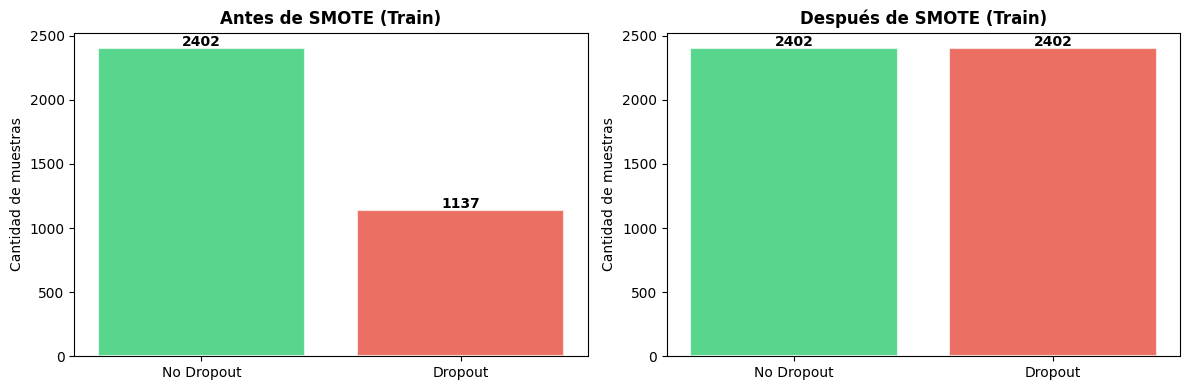


Celda 5 ejecutada correctamente. Ahora puedes correr la Celda 6.


In [ ]:
# ============================================================
# CELDA 5: DIVISIÓN, NORMALIZACIÓN Y BALANCEO CON SMOTE
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

# --- LISTA DE FEATURES (columnas que existen en el dataset) ---
features = [
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Tuition fees up to date',
    'Debtor',
    'Scholarship holder',
    'Age at enrollment',
    'Displaced',
    'Gender',
    'GDP',
    'Unemployment rate',
    'Inflation rate',
    'aprobacion_rate_1',
    'aprobacion_rate_2',
    'variacion_rendimiento',
    'carga_total',
    'riesgo_financiero',
]

X = df_model[features].copy()
y = df_model['dropout'].copy()

# --- IMPUTACIÓN ---
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# --- DIVISIÓN TRAIN/TEST (antes de SMOTE) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# --- NORMALIZACIÓN ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # solo transform, nunca fit

# --- SMOTE solo sobre train ---
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled, y_train
)

print("DISTRIBUCIÓN DE CLASES:")
print("=" * 45)
print(f"Train original : {dict(pd.Series(y_train).value_counts())}")
print(f"Train con SMOTE: {dict(pd.Series(y_train_balanced).value_counts())}")
print(f"Test (sin tocar): {dict(pd.Series(y_test).value_counts())}")
print(f"\nFormas finales:")
print(f"  X_train_balanced : {X_train_balanced.shape}")
print(f"  X_test_scaled    : {X_test_scaled.shape}")

# --- Visualización SMOTE ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_vals, title in [
    (axes[0], pd.Series(y_train),          'Antes de SMOTE (Train)'),
    (axes[1], pd.Series(y_train_balanced), 'Después de SMOTE (Train)'),
]:
    counts = y_vals.value_counts().sort_index()
    ax.bar(['No Dropout', 'Dropout'], counts.values,
           color=['#2ecc71', '#e74c3c'], alpha=0.8,
           edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Cantidad de muestras')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('fase3_smote.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nCelda 5 ejecutada correctamente. Ahora puedes correr la Celda 6.")

Épocas entrenadas     : 37
Clases detectadas     : [0 1]
Mejor validation score: 0.8358


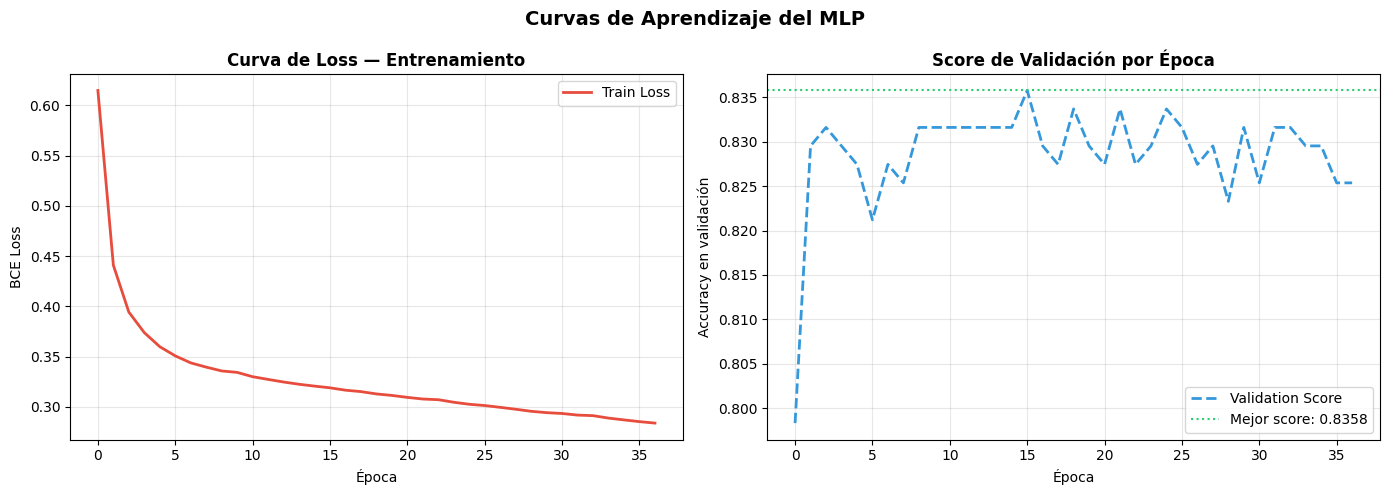

Celda 6 ejecutada correctamente. Ahora puedes correr la Celda 8 (Evaluación).


In [ ]:
# ============================================================
# CELDA 6: MLP CON SCIKIT-LEARN
# ============================================================

from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')

# --- CONFIGURACIÓN DEL MLP ---
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42,
    verbose=False
)

# Entrenamiento
mlp.fit(X_train_balanced, y_train_balanced)

print(f"Épocas entrenadas     : {mlp.n_iter_}")
print(f"Clases detectadas     : {mlp.classes_}")

# best_loss_ es None con early_stopping=True, usar best_validation_score_
if mlp.best_loss_ is not None:
    print(f"Mejor loss            : {mlp.best_loss_:.4f}")
else:
    print(f"Mejor validation score: {mlp.best_validation_score_:.4f}")

# --- CURVA DE APRENDIZAJE ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Loss de entrenamiento
axes[0].plot(mlp.loss_curve_, color='#e74c3c', linewidth=2, label='Train Loss')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Curva de Loss — Entrenamiento', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Subplot 2: Validation score por época
axes[1].plot(mlp.validation_scores_, color='#3498db', linewidth=2,
             linestyle='--', label='Validation Score')
axes[1].axhline(y=mlp.best_validation_score_, color='#2ecc71',
                linewidth=1.5, linestyle=':', label=f'Mejor score: {mlp.best_validation_score_:.4f}')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy en validación')
axes[1].set_title('Score de Validación por Época', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Curvas de Aprendizaje del MLP', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fase4_curva_aprendizaje.png', dpi=150, bbox_inches='tight')
plt.show()
print("Celda 6 ejecutada correctamente. Ahora puedes correr la Celda 8 (Evaluación).")


MLPDesercion(
  (net): Sequential(
    (0): Linear(in_features=18, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

Parámetros entrenables: 3,329
Época  20 | Train Loss: 0.3524 | Val Loss: 0.3165
Época  40 | Train Loss: 0.3318 | Val Loss: 0.3173
Época  60 | Train Loss: 0.3105 | Val Loss: 0.3098
Época  80 | Train Loss: 0.3036 | Val Loss: 0.3065
Época 100 | Train Loss: 0.2951 | Val Loss: 0.3120


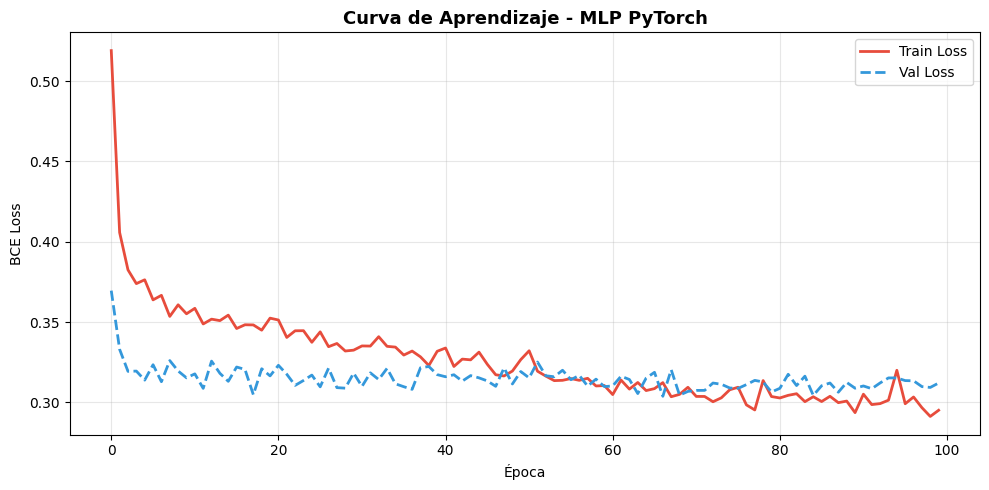

Entrenamiento completado.


In [ ]:
# ============================================================
# CELDA 7: MLP CON PYTORCH (IMPLEMENTACIÓN AVANZADA)
# ============================================================

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Convertir a tensores
X_tr = torch.FloatTensor(X_train_balanced)
y_tr = torch.FloatTensor(y_train_balanced.astype(float))
X_te = torch.FloatTensor(X_test_scaled)
y_te = torch.FloatTensor(y_test.values.astype(float))

# Dataset y DataLoader
train_dataset = TensorDataset(X_tr, y_tr)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True)

# ---- ARQUITECTURA DEL MLP ----
class MLPDesercion(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Dropout(p=0.30),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=0.30),
            nn.Linear(32, 1),
            nn.Sigmoid()           # Salida: probabilidad de deserción
        )
    def forward(self, x):
        return self.net(x).squeeze()

# Instanciar modelo
n_features = X_train_balanced.shape[1]
model = MLPDesercion(n_features)
print(model)
print(f"\nParámetros entrenables: "
      f"{sum(p.numel() for p in model.parameters()):,}")

# Pesos de clase para manejar desbalance (alternativa a SMOTE)
pos_weight = torch.tensor([y_train.value_counts()[0] /
                            y_train.value_counts()[1]])
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001,
                              weight_decay=1e-4)

# ---- ENTRENAMIENTO ----
EPOCHS = 100
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    # Validación
    model.eval()
    with torch.no_grad():
        val_preds = model(X_te)
        val_loss  = criterion(val_preds, y_te)

    train_losses.append(np.mean(batch_losses))
    val_losses.append(val_loss.item())

    if (epoch + 1) % 20 == 0:
        print(f"Época {epoch+1:3d} | "
              f"Train Loss: {train_losses[-1]:.4f} | "
              f"Val Loss: {val_losses[-1]:.4f}")

# Gráfico de curvas
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='#e74c3c', linewidth=2)
plt.plot(val_losses,   label='Val Loss',   color='#3498db', linewidth=2,
         linestyle='--')
plt.xlabel('Época'); plt.ylabel('BCE Loss')
plt.title('Curva de Aprendizaje - MLP PyTorch', fontsize=13, fontweight='bold')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fase4_pytorch_learning.png', dpi=150, bbox_inches='tight')
plt.show()
print("Entrenamiento completado.")


REPORTE DE CLASIFICACIÓN (umbral=0.40)
              precision    recall  f1-score   support

  No Dropout       0.94      0.84      0.88       601
     Dropout       0.72      0.88      0.79       284

    accuracy                           0.85       885
   macro avg       0.83      0.86      0.84       885
weighted avg       0.87      0.85      0.85       885

ROC-AUC:      0.9306
AUC-PR:       0.9002


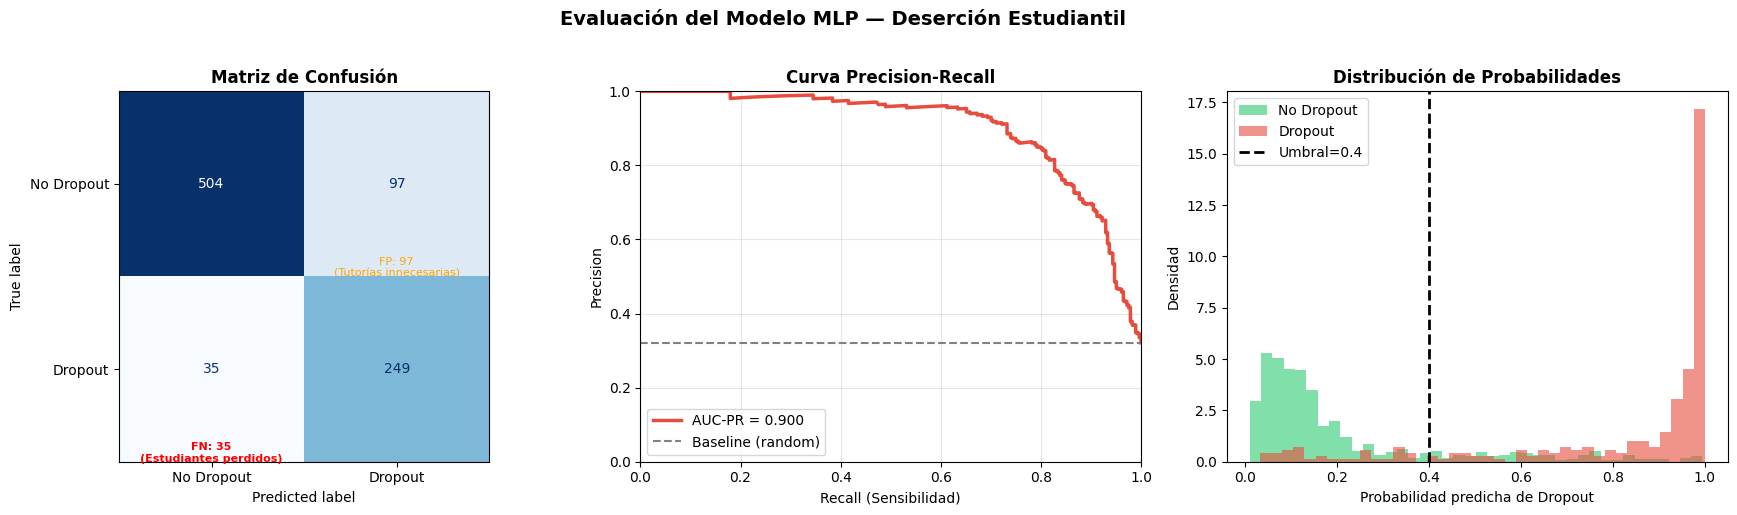

In [ ]:
# ============================================================
# CELDA 8: EVALUACIÓN COMPLETA DEL MODELO
# ============================================================

from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_auc_score,
    average_precision_score, ConfusionMatrixDisplay
)

# --- Predicciones ---
# Para Scikit-Learn:
y_pred_proba = mlp.predict_proba(X_test_scaled)[:, 1]
y_pred       = mlp.predict(X_test_scaled)

# Si usas PyTorch:
# model.eval()
# with torch.no_grad():
#     y_pred_proba = model(X_te).numpy()
# y_pred = (y_pred_proba > 0.5).astype(int)

# --- Umbral: ajustarlo puede mejorar el Recall ---
THRESHOLD = 0.40  # Más bajo = más Recall (menos FN)
y_pred_custom = (y_pred_proba >= THRESHOLD).astype(int)

print("=" * 55)
print("REPORTE DE CLASIFICACIÓN (umbral=0.40)")
print("=" * 55)
print(classification_report(y_test, y_pred_custom,
      target_names=['No Dropout', 'Dropout']))

print(f"ROC-AUC:      {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"AUC-PR:       {average_precision_score(y_test, y_pred_proba):.4f}")

# --- Figura con 3 subplots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Matriz de confusión
cm = confusion_matrix(y_test, y_pred_custom)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Dropout', 'Dropout'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión', fontsize=12, fontweight='bold')

# Anotar FP y FN
axes[0].text(0, 1.5,
    f"FN: {cm[1,0]}\n(Estudiantes perdidos)", ha='center',
    fontsize=8, color='red', fontweight='bold')
axes[0].text(1, 0.5,
    f"FP: {cm[0,1]}\n(Tutorías innecesarias)", ha='center',
    fontsize=8, color='orange')

# 2. Curva Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
auc_pr = average_precision_score(y_test, y_pred_proba)
axes[1].plot(recall, precision, color='#e74c3c', linewidth=2.5,
             label=f'AUC-PR = {auc_pr:.3f}')
axes[1].axhline(y=df_model['dropout'].mean(), color='gray',
                linestyle='--', label='Baseline (random)')
axes[1].set_xlabel('Recall (Sensibilidad)'); axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall', fontsize=12, fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1])

# 3. Distribución de probabilidades predichas
axes[2].hist(y_pred_proba[y_test == 0], bins=40, alpha=0.6,
             label='No Dropout', color='#2ecc71', density=True)
axes[2].hist(y_pred_proba[y_test == 1], bins=40, alpha=0.6,
             label='Dropout', color='#e74c3c', density=True)
axes[2].axvline(x=THRESHOLD, color='black', linewidth=2,
                linestyle='--', label=f'Umbral={THRESHOLD}')
axes[2].set_xlabel('Probabilidad predicha de Dropout')
axes[2].set_ylabel('Densidad')
axes[2].set_title('Distribución de Probabilidades', fontsize=12, fontweight='bold')
axes[2].legend()

plt.suptitle('Evaluación del Modelo MLP — Deserción Estudiantil',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fase5_evaluacion.png', dpi=150, bbox_inches='tight')
plt.show()


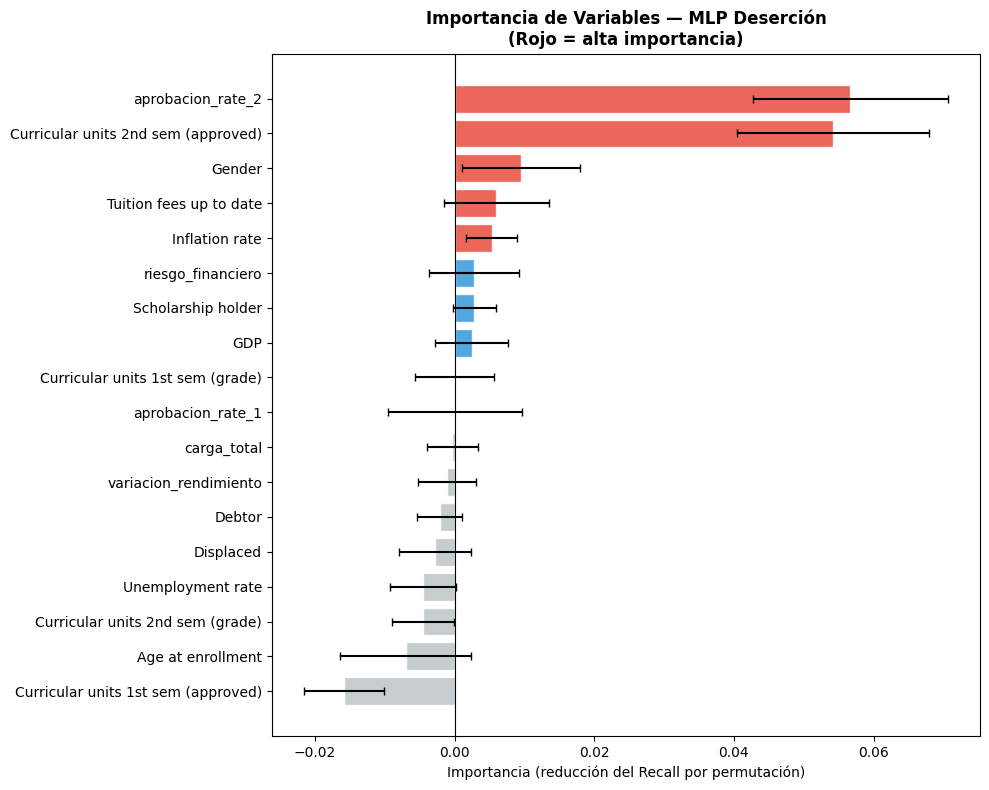


TOP 5 variables más importantes para predecir deserción:
                                Feature  Importance       Std
14                    aprobacion_rate_2    0.056690  0.013947
2   Curricular units 2nd sem (approved)    0.054225  0.013746
9                                Gender    0.009507  0.008487
4               Tuition fees up to date    0.005986  0.007560
12                       Inflation rate    0.005282  0.003608


In [ ]:
# ============================================================
# CELDA 9: IMPORTANCIA DE CARACTERÍSTICAS (PERMUTATION)
# ============================================================

from sklearn.inspection import permutation_importance

# Calcular importancia por permutación (funciona con cualquier modelo)
result = permutation_importance(
    mlp, X_test_scaled, y_test,
    n_repeats=10, random_state=42,
    scoring='recall'
)

feat_import = pd.DataFrame({
    'Feature': features,
    'Importance': result.importances_mean,
    'Std': result.importances_std
}).sort_values('Importance', ascending=True)

# Gráfico horizontal
plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if i > feat_import['Importance'].quantile(0.75)
          else '#3498db' if i > 0
          else '#bdc3c7'
          for i in feat_import['Importance']]
plt.barh(feat_import['Feature'], feat_import['Importance'],
         color=colors, alpha=0.85, xerr=feat_import['Std'],
         capsize=3, edgecolor='white')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Importancia (reducción del Recall por permutación)')
plt.title('Importancia de Variables — MLP Deserción\n(Rojo = alta importancia)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fase5_importancia_vars.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTOP 5 variables más importantes para predecir deserción:")
print(feat_import.sort_values('Importance', ascending=False).head(5).to_string())
